In [11]:
# Cell 1: Imports
import numpy as np              # NumPy: For numerical operations, especially arrays and matrices.
import pandas as pd             # Pandas: For data manipulation and analysis, particularly DataFrames.
import random                   # random: For generating pseudo-random numbers and random choices.
import matplotlib.pyplot as plt # Matplotlib.pyplot: For creating static, animated, and interactive visualizations.
from collections import deque   # collections.deque: A double-ended queue for efficient appends and pops from both ends.
import sys                      # sys: For accessing system-specific parameters and functions.
import time                     # time: For time-related functions, like getting current time or pausing execution.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [12]:
# Cell 2: HybridPowerFlowOptimizer Class
class HybridPowerFlowOptimizer:
    """
    Optimizes power flow using a hybrid metaheuristic approach.
    The primary objectives are to satisfy all constraints while minimizing
    load shedding and then minimizing generator deviation/cost.
    All calculations are performed with a precision of two decimal places.
    """

    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, initial_B, memory_size=100):
        """
        Initializes the HybridPowerFlowOptimizer.
        """
        # Round all inputs to two decimal places upon initialization.
        self.A = np.round(A_matrix, 2)
        self.line_limits = np.round(np.array(line_limits, dtype=np.float64), 2)
        self.num_lines = self.A.shape[0]
        self.num_buses = self.A.shape[1]
        # Adjust tolerance to match the new precision.
        self.tolerance = 1e-2

        # Store raw initial state to calculate true load shed amount against user's original input.
        self.raw_initial_B = np.round(initial_B.copy().flatten(), 2)
        # This working copy will be clamped and balanced, serving as the reference for generator deviation.
        self.initial_B = self.raw_initial_B.copy()

        # Identify generator and load buses from the raw input.
        self.gen_indices = np.where(self.raw_initial_B > self.tolerance)[0]
        self.load_indices = np.where(self.raw_initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0:
            raise ValueError("No generator buses identified (initial B > 0). Cannot proceed.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices})")

        # Define a GLOBAL maximum for total load shedding.
        self.max_total_load_shed = 20.0
        print(f"Load shedding enabled with a maximum TOTAL of {self.max_total_load_shed} units across all loads.")

        # Process and round generator costs and limits.
        flat_gc = np.round(np.array(gen_costs).flatten(), 2)
        flat_gmin = np.round(np.array(gen_limits_min).flatten(), 2)
        flat_gmax = np.round(np.array(gen_limits_max).flatten(), 2)
        if len(flat_gc) != self.num_buses or len(flat_gmin) != self.num_buses or len(flat_gmax) != self.num_buses:
            raise ValueError(f"Generator cost/limit array length mismatch (Expected {self.num_buses})")
        self.gen_costs_only = flat_gc[self.gen_indices]
        self.gen_limits_min_only = flat_gmin[self.gen_indices]
        self.gen_limits_max_only = flat_gmax[self.gen_indices]
        if np.any(self.gen_limits_max_only < self.gen_limits_min_only):
            raise ValueError("Generator Max limit cannot be less than Min limit.")

        # Set load limits: min is the initial value, max is zero (cannot become a generator).
        if len(self.load_indices) > 0:
            self.load_limits_min_only = self.raw_initial_B[self.load_indices]
            self.load_limits_max_only = np.round(np.zeros_like(self.load_limits_min_only), 2)
        else:
            self.load_limits_min_only = np.array([])
            self.load_limits_max_only = np.array([])

        # Clamp and balance the working copy of initial_B to create a valid reference state.
        initial_gen_values = self.initial_B[self.gen_indices]
        clamped_gen_values = np.round(np.clip(initial_gen_values, self.gen_limits_min_only, self.gen_limits_max_only), 2)
        if not np.allclose(initial_gen_values, clamped_gen_values):
            print("Warning: Initial generator B outside limits. Clamping...")
            self.initial_B[self.gen_indices] = clamped_gen_values

        current_total_injection = np.round(np.sum(self.initial_B), 2)
        difference_init = np.round(-current_total_injection, 2)
        num_gens = len(self.gen_indices)
        if abs(difference_init) > self.tolerance * self.num_buses:
            print(f"Warning: Initial injections sum to {current_total_injection:.4f} (≠ 0). Adjusting generators to balance...")
            if num_gens > 0:
                diff_per_gen_init = np.round(difference_init / num_gens, 2)
                adjusted_gens = np.round(self.initial_B[self.gen_indices] + diff_per_gen_init, 2)
                self.initial_B[self.gen_indices] = np.round(np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only), 2)
        
        print("-> Balanced & clamped initial B state (used for deviation reference):", np.round(self.initial_B, 2))

        self.memory = deque(maxlen=100)
        self.stagnation_threshold = 50
        self.diversification_fraction = 0.2

    def _apply_constraints(self, solution_vector):
        sol = np.round(solution_vector.copy().flatten(), 2)
        num_gens = len(self.gen_indices)
        num_loads = len(self.load_indices)

        # Step 1: Apply individual generator and load limits.
        if num_loads > 0:
            sol[self.load_indices] = np.round(np.clip(sol[self.load_indices], self.load_limits_min_only, self.load_limits_max_only), 2)
        if num_gens > 0:
            sol[self.gen_indices] = np.round(np.clip(sol[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only), 2)

        # Step 2: Enforce the GLOBAL load shed limit.
        if num_loads > 0:
            original_loads = self.raw_initial_B[self.load_indices]
            current_loads = sol[self.load_indices]
            total_shed = np.round(np.sum(np.maximum(0, current_loads - original_loads)), 2)

            if total_shed > self.max_total_load_shed + self.tolerance:
                overshoot = np.round(total_shed - self.max_total_load_shed, 2)
                shed_amounts = np.round(np.maximum(0, current_loads - original_loads), 2)
                
                total_shed_from_sheddable_loads = np.round(np.sum(shed_amounts), 2)
                if total_shed_from_sheddable_loads > self.tolerance:
                    reductions = np.round(overshoot * (shed_amounts / total_shed_from_sheddable_loads), 2)
                    sol[self.load_indices] = np.round(sol[self.load_indices] - reductions, 2)

        # Step 3: Enforce power balance.
        if num_gens > 0:
            current_load_sum = np.round(np.sum(sol[self.load_indices]) if num_loads > 0 else 0.0, 2)
            required_gen_sum = np.round(-current_load_sum, 2)
            current_gen_sum = np.round(np.sum(sol[self.gen_indices]), 2)
            difference = np.round(required_gen_sum - current_gen_sum, 2)

            if abs(difference) > self.tolerance:
                adjustment_per_gen = np.round(difference / num_gens, 2)
                adjusted_gens = np.round(sol[self.gen_indices] + adjustment_per_gen, 2)
                sol[self.gen_indices] = np.round(np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only), 2)

        return np.round(sol.reshape(-1, 1), 2)

    def _calculate_fitness(self, solution):
        sol_flat = np.round(solution.flatten(), 2)
        if not np.all(np.isfinite(sol_flat)): return np.inf

        try:
            flows = np.round(np.dot(self.A, sol_flat).flatten(), 2)
        except ValueError: return np.inf
        
        penalty_multiplier = 1e10

        line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        gen_limit_penalty = 0.0
        if len(self.gen_indices) > 0:
            gen_values = sol_flat[self.gen_indices]
            violations_lower_g = np.maximum(0, self.gen_limits_min_only - gen_values)
            violations_upper_g = np.maximum(0, gen_values - self.gen_limits_max_only)
            gen_limit_penalty = penalty_multiplier * (np.sum(violations_lower_g**2) + np.sum(violations_upper_g**2))

        load_limit_penalty = 0.0
        if len(self.load_indices) > 0:
            load_values = sol_flat[self.load_indices]
            violations_lower_l = np.maximum(0, self.load_limits_min_only - load_values)
            violations_upper_l = np.maximum(0, load_values - self.load_limits_max_only)
            load_limit_penalty = penalty_multiplier * (np.sum(violations_lower_l**2) + np.sum(violations_upper_l**2))

        balance_penalty = penalty_multiplier * (np.sum(sol_flat)**2)

        total_shed_amount = 0.0
        load_shed_penalty_component = 0.0
        if len(self.load_indices) > 0:
            original_loads = self.raw_initial_B[self.load_indices]
            current_loads = sol_flat[self.load_indices]
            shed_amounts = np.maximum(0, current_loads - original_loads)
            total_shed_amount = np.sum(shed_amounts)
            load_shed_penalty_component = 1e7 * np.sum(shed_amounts**2)

        total_shed_violation_penalty = 0.0
        if total_shed_amount > self.max_total_load_shed + self.tolerance:
            total_shed_violation_penalty = penalty_multiplier * (total_shed_amount - self.max_total_load_shed)**2

        deviation_penalty_component = 1e5 * self._get_generator_deviation(solution)
        gen_rescheduling_cost = 0.1 * self._get_rescheduling_cost(solution)

        fitness = (line_violation_penalty + gen_limit_penalty + load_limit_penalty + balance_penalty +
                   load_shed_penalty_component + total_shed_violation_penalty +
                   deviation_penalty_component + gen_rescheduling_cost)

        return fitness if np.isfinite(fitness) else np.inf

    def _is_feasible(self, solution, verbose=False):
        if solution is None: return False
        sol_flat = np.round(solution.flatten(), 2)
        if not np.all(np.isfinite(sol_flat)): return False

        flows = np.round(np.dot(self.A, sol_flat).flatten(), 2)
        line_ok = np.all(np.abs(flows) <= self.line_limits + self.tolerance)
        
        gen_ok = True
        if len(self.gen_indices) > 0:
            gen_values = sol_flat[self.gen_indices]
            gen_ok = np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and \
                     np.all(gen_values <= self.gen_limits_max_only + self.tolerance)

        load_ok = True
        if len(self.load_indices) > 0:
            load_values = sol_flat[self.load_indices]
            total_shed = np.round(np.sum(np.maximum(0, load_values - self.raw_initial_B[self.load_indices])), 2)
            load_ok = np.all(load_values >= self.load_limits_min_only - self.tolerance) and \
                      np.all(load_values <= self.load_limits_max_only + self.tolerance) and \
                      total_shed <= self.max_total_load_shed + self.tolerance

        bal_ok = abs(np.sum(sol_flat)) < self.tolerance * self.num_buses
        
        feasible = line_ok and gen_ok and load_ok and bal_ok

        if verbose or not feasible:
            print(f"--- Feasibility Check {'FAILED' if not feasible else 'PASSED'} ---")
            print(f"  Line constraints met: {line_ok}")
            print(f"  Generator limits met: {gen_ok}")
            print(f"  Load limits met: {load_ok}")
            print(f"  Power balance met: {bal_ok}")
            print("-" * 40)
        return feasible

    def _get_generator_deviation(self, solution):
        if len(self.gen_indices) == 0: return 0.0
        sol_flat = np.round(solution.flatten(), 2)
        deviation = np.sum(np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices]))
        return np.round(deviation, 2)

    def _get_rescheduling_cost(self, solution):
        if len(self.gen_indices) == 0: return 0.0
        deviation = np.abs(np.round(solution.flatten(), 2)[self.gen_indices] - self.initial_B[self.gen_indices])
        cost = np.sum(self.gen_costs_only * deviation)
        return np.round(cost, 2)

    def _generate_random_solution(self):
        rand_sol = self.initial_B.copy()
        n_gens = len(self.gen_indices)
        n_loads = len(self.load_indices)

        if n_gens > 0:
            gen_range = self.gen_limits_max_only - self.gen_limits_min_only
            perturbations = np.round((np.random.rand(n_gens) - 0.5) * gen_range * 0.2, 2)
            rand_sol[self.gen_indices] = np.round(np.clip(self.initial_B[self.gen_indices] + perturbations, self.gen_limits_min_only, self.gen_limits_max_only), 2)
        
        if n_loads > 0:
            total_random_shed = np.round(random.random() * self.max_total_load_shed, 2)
            if total_random_shed > self.tolerance:
                shed_distribution = np.random.rand(n_loads)
                shed_distribution /= np.sum(shed_distribution) # Normalize
                shed_amounts_per_load = np.round(total_random_shed * shed_distribution, 2)
                new_loads = np.round(self.raw_initial_B[self.load_indices] + shed_amounts_per_load, 2)
                rand_sol[self.load_indices] = np.round(np.minimum(new_loads, 0), 2)

        return self._apply_constraints(rand_sol)

    def _apply_local_search(self, solution, iteration, max_iterations):
        current_solution = solution.copy()
        current_fitness = self._calculate_fitness(current_solution)
        if not np.isfinite(current_fitness): return solution
        progress_ratio = iteration / max_iterations
        step_scale_factor = 0.1 * (1.0 - progress_ratio) + 0.01 * progress_ratio
        num_attempts = min(5, int(np.sqrt(self.num_buses)))

        for _ in range(num_attempts):
            idx_to_perturb = random.randrange(self.num_buses)
            perturbed_solution = current_solution.copy()
            perturb_range = 1.0
            if idx_to_perturb in self.gen_indices:
                gen_idx_local = np.where(self.gen_indices == idx_to_perturb)[0][0]
                gen_op_range = self.gen_limits_max_only[gen_idx_local] - self.gen_limits_min_only[gen_idx_local]
                perturb_range = max(self.tolerance, gen_op_range) * step_scale_factor
            elif idx_to_perturb in self.load_indices:
                load_idx_local = np.where(self.load_indices == idx_to_perturb)[0][0]
                load_op_range = self.load_limits_max_only[load_idx_local] - self.load_limits_min_only[load_idx_local]
                perturb_range = max(self.tolerance, load_op_range) * step_scale_factor
            
            perturbation = np.round((random.random() - 0.5) * 2 * perturb_range, 2)
            perturbed_solution[idx_to_perturb, 0] += perturbation
            refined_solution = self._apply_constraints(perturbed_solution)
            refined_fitness = self._calculate_fitness(refined_solution)

            if np.isfinite(refined_fitness) and refined_fitness < current_fitness:
                current_solution = refined_solution
                current_fitness = refined_fitness
        return current_solution

    def optimize(self, B_unused, iterations=200, population_size=30):
        print(f"Starting Optimization: Pop={population_size}, Iterations={iterations}")
        initial_state_constrained = self._apply_constraints(self.initial_B)
        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = initial_state_constrained
        fitness_values = [self._calculate_fitness(sol) for sol in initial_population]
        
        try:
            best_idx = np.nanargmin(fitness_values)
            best_fitness = fitness_values[best_idx]
            best_solution = initial_population[best_idx].copy()
        except (ValueError, IndexError):
             print("FATAL: Could not find any valid solution in the initial population. Aborting.")
             return self.initial_B.reshape(-1, 1), [], np.dot(self.A, self.initial_B.reshape(-1,1))

        print(f"Initial Best Fitness: {best_fitness:.4e}")
        fitness_history = [best_fitness]
        algorithm_names = ['OOA', 'KHA', 'SHO']
        algo_success_count = {name: 0 for name in algorithm_names}
        algo_attempts_count = {name: 0 for name in algorithm_names}
        algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}
        adaptation_rate = 0.05
        stagnation_counter = 0
        last_best_fitness = best_fitness

        for iteration in range(iterations):
            total_attempts = sum(algo_attempts_count.values())
            if total_attempts > 0:
                success_rates = {name: algo_success_count[name] / algo_attempts_count[name] if algo_attempts_count[name] > 0 else 0 for name in algorithm_names}
                total_rate = sum(success_rates.values())
                if total_rate > 1e-6:
                    target_probabilities = {name: rate / total_rate for name, rate in success_rates.items()}
                    for name in algorithm_names:
                        algo_probabilities[name] = (1 - adaptation_rate) * algo_probabilities[name] + adaptation_rate * target_probabilities[name]
                    prob_sum = sum(algo_probabilities.values())
                    if prob_sum > 1e-6:
                        algo_probabilities = {name: p / prob_sum for name, p in algo_probabilities.items()}
                    else:
                        algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}
            
            current_weights = list(algo_probabilities.values())
            new_population = []
            current_fitness_values = []
            
            for i in range(population_size):
                algorithm = random.choices(algorithm_names, weights=current_weights, k=1)[0]
                algo_attempts_count[algorithm] += 1
                candidate_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                if algorithm == 'KHA': candidate_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                elif algorithm == 'SHO': candidate_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                
                refined_candidate = self._apply_local_search(candidate_solution, iteration, iterations)
                new_solution = self._apply_constraints(refined_candidate)
                new_fitness = self._calculate_fitness(new_solution)
                new_population.append(new_solution)
                current_fitness_values.append(new_fitness)

                if np.isfinite(new_fitness) and new_fitness < best_fitness:
                    best_fitness = new_fitness
                    best_solution = new_solution.copy()
                    algo_success_count[algorithm] += 1

            initial_population = new_population
            fitness_values = current_fitness_values
            
            if np.isfinite(best_fitness): fitness_history.append(best_fitness)
            if abs(best_fitness - last_best_fitness) < self.tolerance: stagnation_counter += 1
            else: stagnation_counter = 0; last_best_fitness = best_fitness

            if stagnation_counter >= self.stagnation_threshold:
                print(f"Stagnation detected at iteration {iteration}. Diversifying...")
                num_to_replace = int(population_size * self.diversification_fraction)
                worst_indices = np.argsort(fitness_values)[-num_to_replace:]
                for idx in worst_indices:
                    initial_population[idx] = self._generate_random_solution()
                    fitness_values[idx] = self._calculate_fitness(initial_population[idx])
                
                current_best_idx = np.nanargmin(fitness_values)
                if fitness_values[current_best_idx] < best_fitness:
                    best_solution = initial_population[current_best_idx].copy()
                    best_fitness = fitness_values[current_best_idx]
                last_best_fitness = best_fitness
                stagnation_counter = 0

            if iteration % 100 == 0 or iteration == iterations - 1:
                print(f"Iter {iteration}/{iterations}: BestFit={best_fitness:.4e} (Stagnation: {stagnation_counter}/{self.stagnation_threshold})")
        
        final_C = np.dot(self.A, best_solution)
        return best_solution, fitness_history, final_C

    def _apply_orcas_optimization(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy(); best_sol_flat = best_solution_global.flatten(); sol_flat = solution.flatten()
        a = 2 * (1 - (iteration / max_iterations)**2); r1, r2 = random.random(), random.random()
        if r1 < 0.5:
            step = np.round(a * r2 * (best_sol_flat - sol_flat), 2)
            new_solution_flat = sol_flat + step
        else:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_solution_idx = random.choice(other_indices) if other_indices else current_index
            random_solution = population[random_solution_idx].flatten()
            A_param = 2 * a * r1 - a; C_param = 2 * r2
            D_param = np.abs(C_param * random_solution - sol_flat)
            new_solution_flat = random_solution - np.round(A_param * D_param, 2)
        return np.round(np.nan_to_num(new_solution_flat, nan=0).reshape(-1, 1), 2)

    def _apply_krill_herd(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy(); best_sol_flat = best_solution_global.flatten(); sol_flat = solution.flatten()
        Dmax = 0.005 * (1 - iteration / max_iterations); Vf = 0.02; Nmax = 0.01; Dt = 1.0
        N_induced = np.round(Nmax * (best_sol_flat - sol_flat), 2)
        F_foraging = np.round(Vf * (best_sol_flat - sol_flat), 2)
        D_physical = np.round(Dmax * np.random.uniform(-1, 1, sol_flat.shape), 2)
        new_solution_flat = sol_flat + Dt * (N_induced + F_foraging + D_physical)
        return np.round(np.nan_to_num(new_solution_flat, nan=0).reshape(-1, 1), 2)

    def _apply_spotted_hyena(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy(); best_sol_flat = best_solution_global.flatten(); sol_flat = solution.flatten()
        h = 5 - iteration * (5 / max_iterations); B_param = 2 * random.random(); E_param = 2 * h * random.random() - h
        D_best = np.abs(B_param * best_sol_flat - sol_flat)
        X1 = best_sol_flat - np.round(E_param * D_best, 2)
        if abs(E_param) >= 1:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_hyena_idx = random.choice(other_indices) if other_indices else current_index
            random_hyena = population[random_hyena_idx].flatten()
            D_hyena = np.abs(B_param * random_hyena - sol_flat)
            new_solution_flat = random_hyena - np.round(E_param * D_hyena, 2)
        else: new_solution_flat = X1
        return np.round(np.nan_to_num(new_solution_flat, nan=0).reshape(-1, 1), 2)


In [13]:
# Cell 3: Wrapper Function
def optimize_power_flow_free_loadshed(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max,
                                      iterations=2000, population_size=100):
    """
    Wrapper function to initialize and run the HybridPowerFlowOptimizer.
    """
    print("--- Initializing Optimizer with New Logic ---")
    
    # --- MODIFIED LOGIC: Calculate C_unoptimized from raw user input B first. ---
    print("Calculating unoptimized flows from original user-provided injections...")
    try:
        C_unoptimized = np.dot(A, B)
    except Exception as e:
        print(f"Warning: Could not calculate initial flows with raw B: {e}")
        C_unoptimized = np.full((A.shape[0], 1), np.nan)

    try:
        optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)
    except (ValueError, NameError) as e:
        print(f"ERROR initializing optimizer: {e}")
        return B, [], np.full_like(C_unoptimized, np.nan), C_unoptimized, False, {}

    initial_B_from_opt = optimizer.initial_B.reshape(-1, 1)
    
    print("\n--- Checking Initial State Feasibility (Using Optimizer's Processed State) ---")
    optimizer._is_feasible(initial_B_from_opt, verbose=True)

    print("\n--- Starting Optimization ---")
    B_opt, fit_hist, C_opt = optimizer.optimize(None, iterations=iterations, population_size=population_size)

    print("\n--- Checking Final Solution Feasibility ---")
    final_feasible = optimizer._is_feasible(B_opt, verbose=True)
    print(f"\nFinal feasibility: {final_feasible}")

    details = {"gen_indices": optimizer.gen_indices, "load_indices": optimizer.load_indices}
    return B_opt, fit_hist, C_opt, C_unoptimized, final_feasible, details


In [14]:
# Cell 4: Visualization Function
def visualize_results(A, B, B_optimized, C_optimized, C_unoptimized, line_limits,
                      gen_costs, gen_limits_min, gen_limits_max,
                      gen_indices, load_indices, fitness_history):
    """
    Generates and displays enhanced plots and data summaries comparing the 
    initial and optimized states.
    """
    # Apply a clean plot style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    num_lines, num_buses = A.shape
    bus_idx_plot = np.arange(1, num_buses + 1)
    print("\n--- Generating Plots & Summaries ---")

    # --- Plot 1: Line Flows Comparison ---
    fig, ax = plt.subplots(figsize=(14, 7))
    idx = np.arange(1, num_lines + 1)
    bar_width = 0.4
    legend_elements = []

    # Unoptimized flows
    if C_unoptimized.size == num_lines:
        unoptimized_flows_abs = np.abs(C_unoptimized.flatten())
        is_violation = unoptimized_flows_abs > line_limits + 1e-6
        ax.bar(idx - bar_width / 2, unoptimized_flows_abs, width=bar_width, 
               color=np.where(is_violation, 'crimson', 'skyblue'))
        legend_elements.append(Patch(facecolor='skyblue', label='Unoptimized (Within Limit)'))
        if np.any(is_violation):
            legend_elements.append(Patch(facecolor='crimson', label='Unoptimized (Violation)'))

    # Optimized flows
    if C_optimized.size == num_lines:
        ax.bar(idx + bar_width / 2, np.abs(C_optimized.flatten()), width=bar_width, color='forestgreen')
        legend_elements.append(Patch(facecolor='forestgreen', label='Optimized Flow'))

    # Line limits
    ax.plot(idx, line_limits, 'k--', alpha=0.9, label='Line Limit')
    legend_elements.append(Line2D([0], [0], color='k', linestyle='--', label='Line Limit'))

    ax.set_xlabel('Line Index', fontweight='bold')
    ax.set_ylabel('Absolute Power Flow', fontweight='bold')
    ax.set_title('Line Flow Comparison: Initial vs. Optimized', fontweight='bold', fontsize=16)
    ax.legend(handles=legend_elements)
    ax.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Fitness Convergence ---
    if len(fitness_history) > 1:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(fitness_history, '.-', color='royalblue')
        ax.set_xlabel('Iteration', fontweight='bold')
        ax.set_ylabel('Fitness Value (Log Scale)', fontweight='bold')
        ax.set_title('Optimization Convergence', fontweight='bold', fontsize=16)
        ax.set_yscale('log')
        plt.tight_layout()
        plt.show()

    # --- Plot 3: Bus Power Injections ---
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.4
    ax.bar(bus_idx_plot - bar_width/2, B.flatten(), width=bar_width, label='Initial Injections', 
           color=['darkblue' if i in gen_indices else 'skyblue' for i in range(num_buses)], alpha=0.8)
    ax.bar(bus_idx_plot + bar_width/2, B_optimized.flatten(), width=bar_width, label='Optimized Injections',
           color=['darkgreen' if i in gen_indices else 'lightgreen' for i in range(num_buses)], alpha=0.8)

    # Add generator limit ranges as error bars for better visualization
    if len(gen_indices) > 0:
        gen_mids = (gen_limits_max[gen_indices] + gen_limits_min[gen_indices]) / 2
        gen_errors = (gen_limits_max[gen_indices] - gen_limits_min[gen_indices]) / 2
        ax.errorbar(bus_idx_plot[gen_indices] + bar_width/2, gen_mids, yerr=gen_errors,
                    fmt='none', color='black', capsize=5, label='Generator Operating Range', elinewidth=1.5, capthick=1.5)

    ax.set_xlabel('Bus Index', fontweight='bold')
    ax.set_ylabel('Power Injection', fontweight='bold')
    ax.set_title('Bus Power Injections: Initial vs. Optimized', fontweight='bold', fontsize=16)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot 4: Load Analysis (Original, Optimized, Shed) ---
    if len(load_indices) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        original_loads = B.flatten()[load_indices]
        optimized_loads = B_optimized.flatten()[load_indices]
        shed_amounts = np.maximum(0, optimized_loads - original_loads)
        
        load_bus_labels = [f"Bus {i+1}" for i in load_indices]
        load_bus_indices = np.arange(len(load_indices))

        # Stacked bar: show final load + shed amount
        ax.bar(load_bus_indices, original_loads, label='Original Demand', color='cornflowerblue', width=0.5)
        ax.bar(load_bus_indices, shed_amounts, bottom=original_loads, label='Load Shed', color='orangered', width=0.5)

        ax.set_xlabel('Load Bus', fontweight='bold')
        ax.set_ylabel('Power (Negative is Demand)', fontweight='bold')
        ax.set_title('Load Demand Analysis: Original vs. Shed', fontweight='bold', fontsize=16)
        ax.set_xticks(load_bus_indices)
        ax.set_xticklabels(load_bus_labels, rotation=45, ha="right")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # --- Text Summary using Pandas DataFrames ---
    print("\n" + "="*25 + " RESULTS SUMMARY " + "="*25)
    
    # Bus Injections Summary Table
    b_summary_df = pd.DataFrame({
        'Bus': bus_idx_plot,
        'Type': ['Generator' if i in gen_indices else 'Load' for i in range(num_buses)],
        'Initial B': B.flatten(),
        'Optimized B': B_optimized.flatten(),
        'Change': B_optimized.flatten() - B.flatten()
    })
    b_summary_df['Change'] = b_summary_df['Change'].round(2)
    print("\n--- Bus Injection Summary ---")
    print(b_summary_df.to_string(index=False))

    # Line Flow Summary Table
    c_summary_df = pd.DataFrame({
        'Line': np.arange(1, num_lines + 1),
        'Limit': line_limits,
        'Initial Flow': np.abs(C_unoptimized.flatten()),
        'Optimized Flow': np.abs(C_optimized.flatten()),
        'Initial Violation': np.maximum(0, np.abs(C_unoptimized.flatten()) - line_limits),
        'Final Violation': np.maximum(0, np.abs(C_optimized.flatten()) - line_limits)
    })
    c_summary_df = c_summary_df.round(2)
    print("\n\n--- Line Flow Summary ---")
    print(c_summary_df.to_string(index=False))

    # Final Metrics
    total_load_shed = b_summary_df[b_summary_df['Type'] == 'Load']['Change'].sum()
    print(f"\n\nTotal Load Shed: {total_load_shed:.4f}")
    
    try:
        temp_opt = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)
        final_feasible = temp_opt._is_feasible(B_optimized)
        print(f"Final solution feasible: {'YES' if final_feasible else 'NO'}")
    except Exception:
        # Suppress re-initialization prints for the summary check
        pass
        
    print("="*70)


Loading system matrix A from: lock.csv
System dimensions: 20 lines, 14 buses.

========================= New Scenario =========================
Objective: 1. Meet Limits & Minimize Load Shed, 2. Minimize Gen Deviation & Cost

>>> Enter LINE power limits for 20 lines:


  Line limits:  170 100 125 100 50 100 100 100 100 100 100 100 15 100 100 100 100 100 100 100



>>> Enter INITIAL power injections (B) for 14 buses:


  Initial injections (B):  



Input Error: Incorrect number of bus injections.. Please restart the scenario.

========================= New Scenario =========================
Objective: 1. Meet Limits & Minimize Load Shed, 2. Minimize Gen Deviation & Cost

>>> Enter LINE power limits for 20 lines:


...


>>> Enter INITIAL power injections (B) for 14 buses:


  Initial injections (B):  235 61.3 -214.2 -1.4 -1 -11.2 0 0 -29.50 -9 -3.5 -6.1 -5.5 -14.9



>>> Enter GENERATOR data for buses: [1 2]:


    G1 cost:  8.34
    G1 min limit:  -10
    G1 max limit:  200
    G2 cost:  8.34
    G2 min limit:  -10
    G2 max limit:  200



========================= Running Optimization =========================
--- Initializing Optimizer with New Logic ---
Calculating unoptimized flows from original user-provided injections...
Identified 2 generator buses (indices: [0 1])
Identified 12 load buses (indices: [ 2  3  4  5  6  7  8  9 10 11 12 13])
Load shedding enabled with a maximum TOTAL of 20.0 units across all loads.
-> Balanced & clamped initial B state (used for deviation reference): [ 200.    78.8 -214.2   -1.4   -1.   -11.2    0.     0.   -29.5   -9.
   -3.5   -6.1   -5.5  -14.9]

--- Checking Initial State Feasibility (Using Optimizer's Processed State) ---
--- Feasibility Check FAILED ---
  Line constraints met: True
  Generator limits met: True
  Load limits met: True
  Power balance met: False
----------------------------------------

--- Starting Optimization ---
Starting Optimization: Pop=100, Iterations=2000
Initial Best Fitness: 1.6407e+08
Iter 0/2000: BestFit=1.4195e+08 (Stagnation: 0/50)
Iter 100/2000: Be

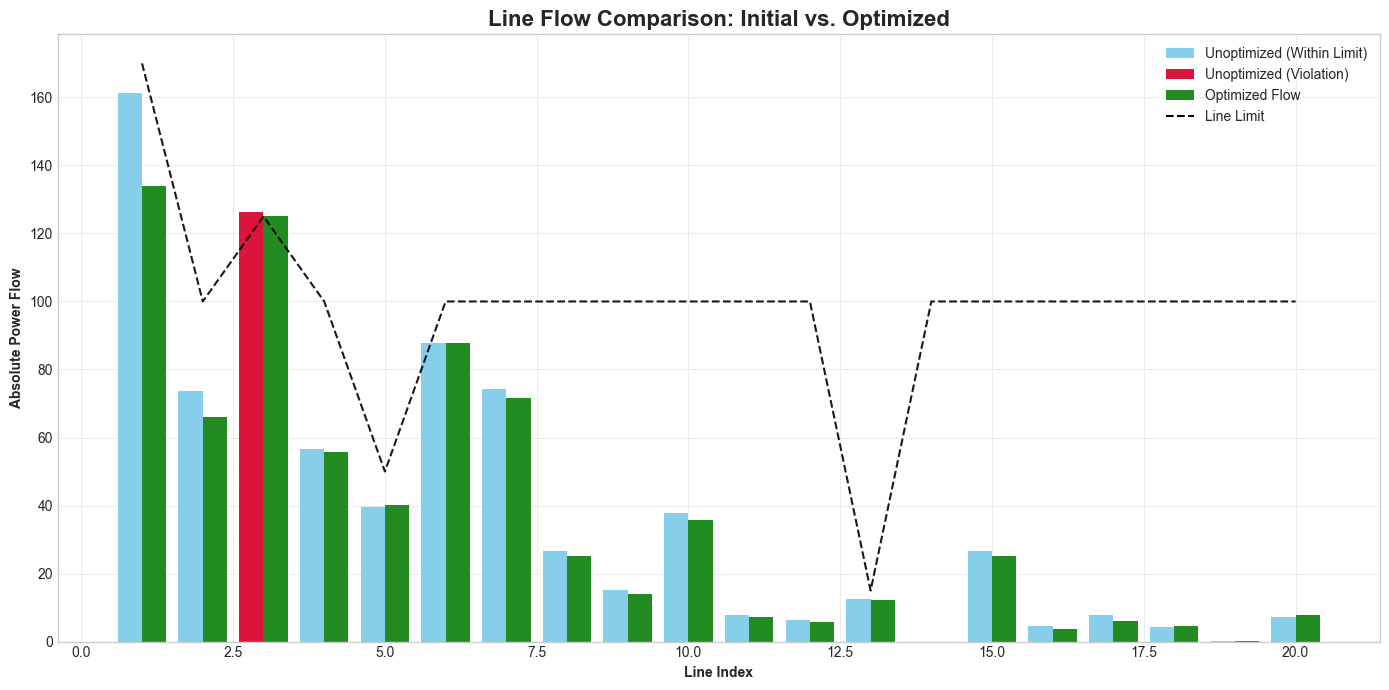

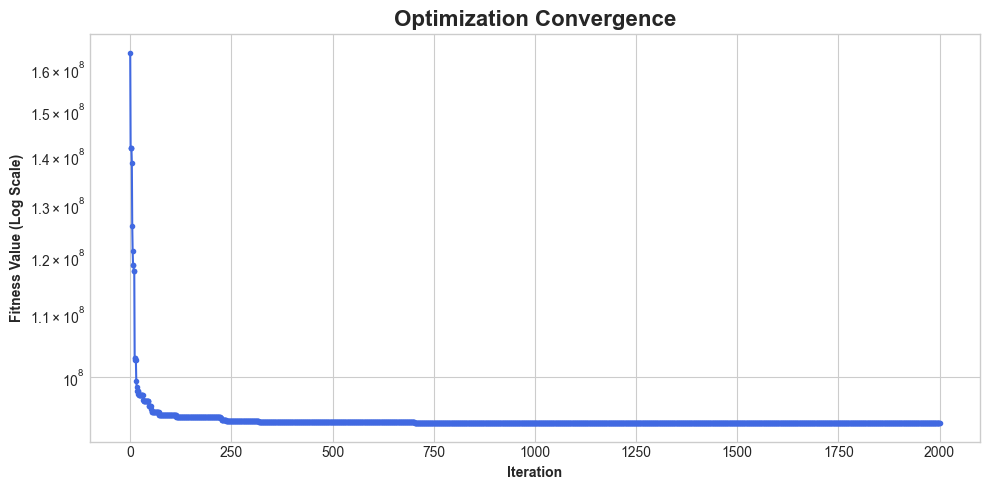

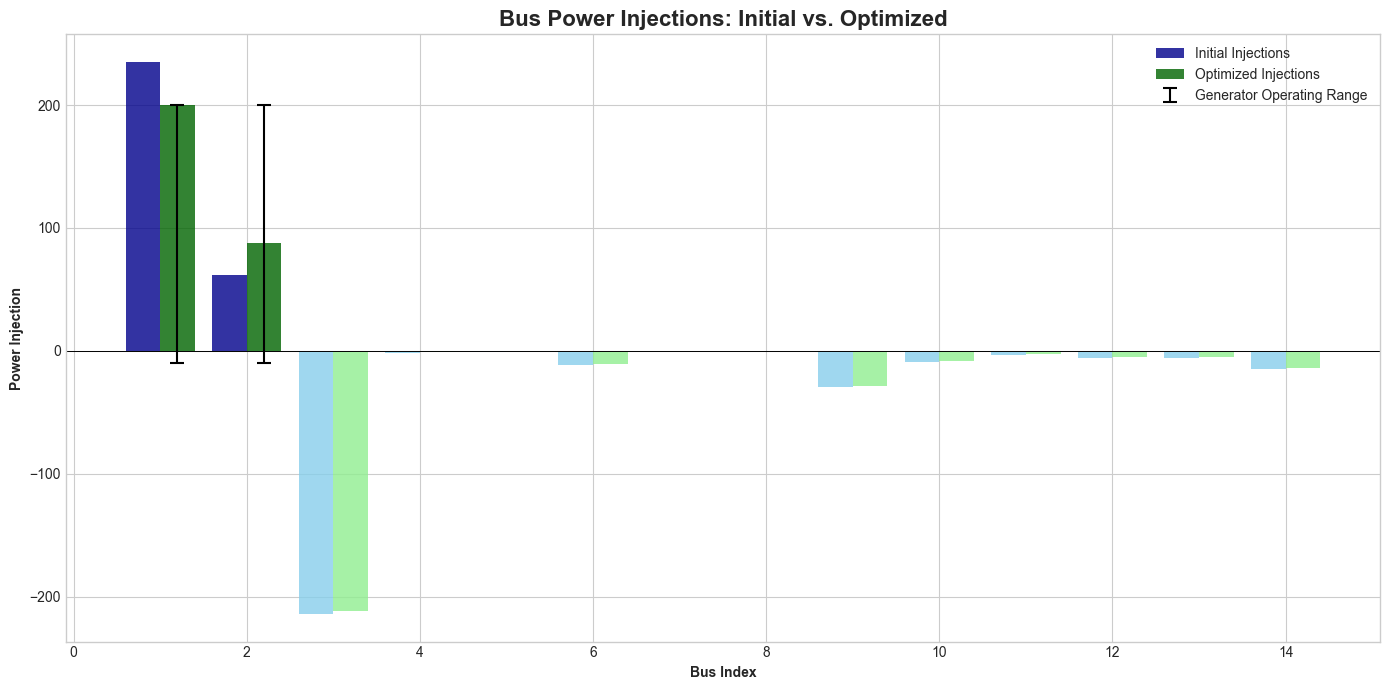

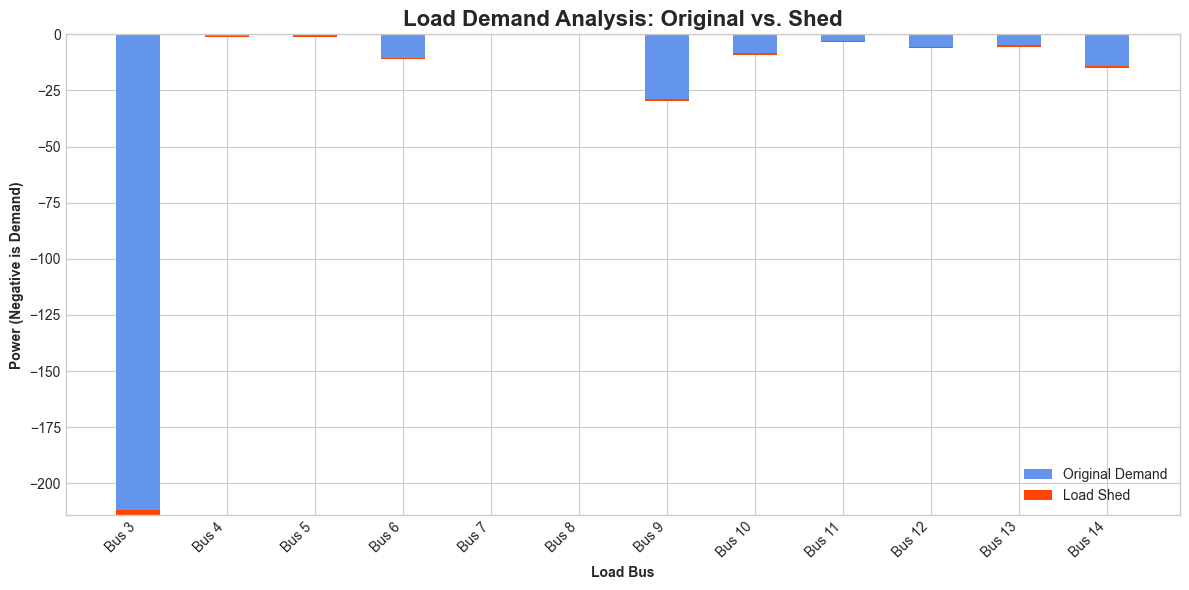


========================= RESULTS SUMMARY =========================

--- Bus Injection Summary ---
 Bus      Type  Initial B  Optimized B  Change
   1 Generator      235.0       200.00  -35.00
   2 Generator       61.3        87.93   26.63
   3      Load     -214.2      -211.96    2.24
   4      Load       -1.4        -0.58    0.82
   5      Load       -1.0        -0.35    0.65
   6      Load      -11.2       -10.57    0.63
   7      Load        0.0         0.00    0.00
   8      Load        0.0         0.00    0.00
   9      Load      -29.5       -28.78    0.72
  10      Load       -9.0        -8.28    0.72
  11      Load       -3.5        -2.81    0.69
  12      Load       -6.1        -5.44    0.66
  13      Load       -5.5        -4.95    0.55
  14      Load      -14.9       -14.21    0.69


--- Line Flow Summary ---
 Line  Limit  Initial Flow  Optimized Flow  Initial Violation  Final Violation
    1  170.0        161.38          134.04                0.0             0.00
    2  10


Save detailed results to a text file? (y/n):  y
Enter filename (default: power_flow_results.txt):  case_3.txt


Attempting to save results to case_3.txt...
Results successfully saved to case_3.txt



Run another scenario? (y/n): n



Script finished.


In [16]:
# Cell 5: Main Execution Block (No changes needed, interacts with the updated wrapper)
if __name__ == "__main__":
    matrix_file_name = 'lock.csv'
    try:
        print(f"Loading system matrix A from: {matrix_file_name}")
        A = pd.read_csv(matrix_file_name, header=None).to_numpy()
        if A.ndim != 2 or A.shape[0] == 0 or A.shape[1] == 0:
            raise ValueError("Loaded matrix A is not valid.")
    except Exception as e:
        print(f"FATAL ERROR reading matrix file '{matrix_file_name}': {e}. Exiting.")
        sys.exit()
    
    num_lines_main, num_buses_main = A.shape
    print(f"System dimensions: {num_lines_main} lines, {num_buses_main} buses.")

    while True:
        print("\n" + "="*25 + " New Scenario " + "="*25)
        print("Objective: 1. Meet Limits & Minimize Load Shed, 2. Minimize Gen Deviation & Cost")

        try:
            print(f"\n>>> Enter LINE power limits for {num_lines_main} lines:")
            limits_str = input("  Line limits: ")
            line_limits_input = np.abs(np.array([float(x) for x in limits_str.split()]))
            if len(line_limits_input) != num_lines_main: raise ValueError("Incorrect number of line limits.")

            print(f"\n>>> Enter INITIAL power injections (B) for {num_buses_main} buses:")
            b_str = input("  Initial injections (B): ")
            B_input = np.array([float(x) for x in b_str.split()]).reshape(-1, 1)
            if len(B_input) != num_buses_main: raise ValueError("Incorrect number of bus injections.")
            
            temp_gen_indices = np.where(B_input.flatten() > 1e-6)[0]
            if len(temp_gen_indices) == 0:
                print("\nERROR: No Generators found in B input. Restarting scenario.")
                continue

            gen_costs_input = np.zeros(num_buses_main)
            gen_limits_min_input = np.zeros(num_buses_main)
            gen_limits_max_input = np.zeros(num_buses_main)
            print(f"\n>>> Enter GENERATOR data for buses: {temp_gen_indices+1}:")
            for i in temp_gen_indices:
                cost_str = input(f"    G{i+1} cost: ")
                gen_costs_input[i] = float(cost_str)
                min_str = input(f"    G{i+1} min limit: ")
                gen_limits_min_input[i] = float(min_str)
                max_str = input(f"    G{i+1} max limit: ")
                gen_limits_max_input[i] = float(max_str)
                if gen_limits_max_input[i] < gen_limits_min_input[i]:
                    raise ValueError(f"Max limit for G{i+1} is less than its min limit.")

        except Exception as e:
            print(f"\nInput Error: {e}. Please restart the scenario.")
            continue

        print("\n" + "="*25 + " Running Optimization " + "="*25)
        start_time = time.time()
        B_optimized, fitness_history, C_optimized, C_unoptimized, final_feasible, opt_details = optimize_power_flow_free_loadshed(
            A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input,
            iterations=2000, population_size=100
        )
        print(f"Optimization Duration: {time.time() - start_time:.2f} seconds")

        print("\n" + "="*25 + " Optimization Finished " + "="*25)
        
        # --- ADDED PRINT STATEMENT FOR THE FINAL SOLUTION ---
        print("\nFinal Optimized Solution (B_optimized):")
        print(B_optimized.flatten())
        # --- END OF ADDED CODE ---

        # --- Visualize Results ---
        visualize_results(A, B_input, B_optimized, C_optimized, C_unoptimized, line_limits_input,
                          gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                          opt_details.get("gen_indices", []), opt_details.get("load_indices", []),
                          fitness_history)
        
        # --- ADDED FUNCTION TO SAVE RESULTS TO A FILE ---
        if final_feasible:
            try:
                save = input("\nSave detailed results to a text file? (y/n): ").strip().lower()
                if save == 'y':
                    default_fname = "power_flow_results.txt"
                    fname = input(f"Enter filename (default: {default_fname}): ").strip()
                    if not fname: fname = default_fname

                    print(f"Attempting to save results to {fname}...")
                    with open(fname, 'w') as f:
                        f.write("Power Flow Optimization Results\n")
                        f.write("="*30+"\n\n")
                        f.write(f"Timestamp: {time.ctime()}\n\n")

                        f.write("--- Initial Conditions ---\n")
                        f.write("Initial B (Bus Injections):\n")
                        np.savetxt(f, B_input, fmt='%.2f', header='Bus Injections', footer='\n')
                        
                        f.write("Line Limits:\n")
                        np.savetxt(f, line_limits_input.reshape(1, -1), fmt='%.2f', header='Limits', footer='\n')

                        f.write("--- Optimized Results ---\n")
                        f.write(f"Final Solution Feasible: {'YES'}\n")
                        
                        f.write("\nOptimized B (Bus Injections):\n")
                        np.savetxt(f, B_optimized, fmt='%.2f', header='Optimized Injections', footer='\n')

                        f.write("Initial C (Line Flows):\n")
                        np.savetxt(f, C_unoptimized, fmt='%.2f', header='Flows', footer='\n')
                        
                        f.write("Optimized C (Line Flows):\n")
                        np.savetxt(f, C_optimized, fmt='%.2f', header='Optimized Flows', footer='\n')
                        
                        gen_dev = 0
                        load_shed = 0
                        gen_indices_viz = opt_details.get("gen_indices", [])
                        load_indices_viz = opt_details.get("load_indices", [])
                        
                        if len(gen_indices_viz) > 0:
                            initial_B_gens = B_input.flatten()[gen_indices_viz]
                            optimized_B_gens = B_optimized.flatten()[gen_indices_viz]
                            gen_dev = np.sum(np.abs(optimized_B_gens - initial_B_gens))
                        
                        if len(load_indices_viz) > 0:
                            initial_B_loads = B_input.flatten()[load_indices_viz]
                            optimized_B_loads = B_optimized.flatten()[load_indices_viz]
                            load_shed = np.sum(np.maximum(0, optimized_B_loads - initial_B_loads))

                        f.write("\n--- Summary Metrics ---\n")
                        f.write(f"Total Generator Deviation: {gen_dev:.2f}\n")
                        f.write(f"Total Load Shed: {load_shed:.2f}\n")
                        
                    print(f"Results successfully saved to {fname}")

            except Exception as e:
                print(f"Error saving results to file: {e}")
        else:
            print("\nFinal solution was not feasible. Results not saved.")
        # --- END OF ADDED SAVE FUNCTIONALITY ---

        run_again = input("\nRun another scenario? (y/n):").strip().lower()
        if run_again != 'y':
            break
            
    print("\nScript finished.")


In [ ]:
170 100 125 100 50 100 100 100 100 100 100 100 15 100 100 100 100 100 100 100 # limits

In [ ]:
219 18.3 -94.2 -47.8 -7.6 -11.2 0 0 -29.5 -9 -3.5 -6.1 -13.5 -14.9 # case 1

In [ ]:
241 28.3 -94.2 -47.8 -47.6 -11.2 0 0 -29.50 -9 -3.5 -6.1 -5.5 -14.9 # case 2

In [ ]:
235 61.3 -214.2 -1.4 -1 -11.2 0 0 -29.50 -9 -3.5 -6.1 -5.5 -14.9 # case 3

In [50]:
200.00+54.56-93.53-46.47-45.80-9.60+0.00+0.00-28.04-7.45-1.91-4.52-3.90-13.34 # optimized power injection

5.329070518200751e-15

In [ ]:
0.000000000000005329070518200751 # converted to real number

In [52]:
241.00+28.30-94.20-47.80-47.60-11.20+0.00+0.00-29.50-9.00-3.50-6.10-5.50-14.90 # unoptimized power injection

1.2434497875801753e-14

In [ ]:
0.000000000000012434497875801753 # converted to real number

In [54]:
-41+26.26+0.67+1.33+1.8+1.6+1.46+1.55+1.59+1.58+1.6+1.56 # delta(P_injection)

1.7763568394002505e-15

In [ ]:
0.0000000000000017763568394002505 # converted to real number